# Proyek Analisis Data: Klasifikasi Sampah Daur Ulang
- **Nama:** [Isi Nama Anda]
- **Email:** [Isi Email Anda]
- **ID Dicoding:** [Isi Username Dicoding]

## Menentukan Pertanyaan Bisnis

- Bagaimana distribusi jumlah gambar pada setiap kategori sampah, dan seberapa besar tingkat ketidakseimbangannya?
- Apakah karakteristik gambar (dimensi dan ukuran file) berbeda antar kategori sehingga perlu perlakuan preprocessing yang berbeda?

## Import Semua Packages/Library yang Digunakan

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

## Data Wrangling

### Gathering Data

In [3]:
# 1) Coba unduh dataset dari Kaggle
# 2) Jika gagal (misalnya belum set kredensial Kaggle), gunakan folder lokal.
DATASET_SLUG = "fathurrahmanalfarizy/sampah-daur-ulang"
FALLBACK_LOCAL_DIR = Path("./sampah-daur-ulang")

try:
    import kagglehub

    dataset_path = Path(kagglehub.dataset_download(DATASET_SLUG))
    print(f"Dataset berhasil diunduh dari Kaggle ke: {dataset_path}")
except Exception as err:
    dataset_path = FALLBACK_LOCAL_DIR
    print("Unduh otomatis via Kaggle gagal. Menggunakan folder lokal.")
    print(f"Alasan: {err}")

if not dataset_path.exists():
    raise FileNotFoundError(
        f"Folder dataset tidak ditemukan: {dataset_path}. "
        "Silakan unduh manual dari Kaggle lalu ekstrak ke folder tersebut."
    )

# Beberapa rilis dataset membungkus kelas di dalam folder "DATASETS".
root_dir = dataset_path
top_dirs = [d for d in dataset_path.iterdir() if d.is_dir()]
if len(top_dirs) == 1 and top_dirs[0].name.lower() in {"datasets", "dataset", "data"}:
    root_dir = top_dirs[0]

image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
records = []

class_dirs = [d for d in root_dir.iterdir() if d.is_dir()]
if not class_dirs:
    raise ValueError("Tidak ada folder kelas yang ditemukan pada dataset.")

for class_dir in class_dirs:
    for img_path in class_dir.rglob("*"):
        if img_path.suffix.lower() in image_exts:
            records.append(
                {
                    "file_path": str(img_path.resolve()),
                    "class_label": class_dir.name,
                    "file_name": img_path.name,
                    "file_ext": img_path.suffix.lower(),
                }
            )

raw_df = pd.DataFrame(records)

print(f"Jumlah baris metadata mentah: {len(raw_df):,}")
print(f"Jumlah kelas: {raw_df['class_label'].nunique()}")
raw_df.head()

Dataset berhasil diunduh dari Kaggle ke: C:\Users\Lenovo\.cache\kagglehub\datasets\fathurrahmanalfarizy\sampah-daur-ulang\versions\5
Jumlah baris metadata mentah: 7,014
Jumlah kelas: 6


,file_path,class_label,file_name,file_ext
0,C:\Users\Lenovo\.cache\kagglehub\datasets\fathurrahmanalfarizy\sampah-daur-ulang\versions\5\DATASETS\Kaca\R_3850.jpg,Kaca,R_3850.jpg,.jpg
1,C:\Users\Lenovo\.cache\kagglehub\datasets\fathurrahmanalfarizy\sampah-daur-ulang\versions\5\DATASETS\Kaca\R_3851.jpg,Kaca,R_3851.jpg,.jpg
2,C:\Users\Lenovo\.cache\kagglehub\datasets\fathurrahmanalfarizy\sampah-daur-ulang\versions\5\DATASETS\Kaca\R_3852.jpg,Kaca,R_3852.jpg,.jpg
3,C:\Users\Lenovo\.cache\kagglehub\datasets\fathurrahmanalfarizy\sampah-daur-ulang\versions\5\DATASETS\Kaca\R_3853.jpg,Kaca,R_3853.jpg,.jpg
4,C:\Users\Lenovo\.cache\kagglehub\datasets\fathurrahmanalfarizy\sampah-daur-ulang\versions\5\DATASETS\Kaca\R_3854.jpg,Kaca,R_3854.jpg,.jpg


**Insight:**
- Dataset berhasil dibentuk menjadi tabel metadata dari struktur folder gambar, sehingga data siap diproses dengan pandas.
- Sumber data bersifat image classification (6 kelas), jadi unit analisis utama adalah per file gambar.

### Assessing Data

In [4]:
print("=== Struktur Data ===")
raw_df.info()

print("\n=== Missing Values ===")
print(raw_df.isna().sum())

print("\n=== Duplikasi ===")
print(f"Duplikasi file_path: {raw_df.duplicated(subset=['file_path']).sum()}")
print(f"Duplikasi file_name dalam kelas sama: {raw_df.duplicated(subset=['class_label', 'file_name']).sum()}")

print("\n=== Distribusi Kelas ===")
class_dist = (
    raw_df["class_label"]
    .value_counts()
    .rename_axis("class_label")
    .reset_index(name="n_images")
)
class_dist["pct"] = (class_dist["n_images"] / class_dist["n_images"].sum() * 100).round(2)
print(class_dist)

print("\n=== Distribusi Ekstensi File ===")
print(raw_df["file_ext"].value_counts())

=== Struktur Data ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7014 entries, 0 to 7013
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   file_path    7014 non-null   object
 1   class_label  7014 non-null   object
 2   file_name    7014 non-null   object
 3   file_ext     7014 non-null   object
dtypes: object(4)
memory usage: 219.3+ KB

=== Missing Values ===
file_path      0
class_label    0
file_name      0
file_ext       0
dtype: int64

=== Duplikasi ===
Duplikasi file_path: 0
Duplikasi file_name dalam kelas sama: 0

=== Distribusi Kelas ===
  class_label  n_images    pct
0      Kertas      1807  25.76
1     Plastik      1257  17.92
2       Logam      1210  17.25
3        Kaca      1110  15.83
4      Residu      1006  14.34
5      Kardus       624   8.90

=== Distribusi Ekstensi File ===
file_ext
.jpg    7014
Name: count, dtype: int64


**Insight:**
- Tahap assessing menampilkan isu kualitas data seperti duplikasi, missing values, dan perbedaan distribusi jumlah gambar per kelas.
- Ketimpangan kelas (class imbalance) dapat langsung diukur dari proporsi setiap kelas untuk menentukan strategi preprocessing/training.

### Cleaning Data

In [5]:
df = raw_df.copy()

# Standarisasi label kelas
df["class_label"] = df["class_label"].astype(str).str.strip().str.title()

# Hapus duplikasi dan nilai kosong
df = df.drop_duplicates(subset=["file_path"])
df = df.dropna(subset=["file_path", "class_label", "file_name", "file_ext"])

# Validasi file gambar sambil ekstrak metadata
clean_records = []
corrupted_files = []

for row in df.itertuples(index=False):
    path = Path(row.file_path)
    try:
        if not path.exists():
            corrupted_files.append(row.file_path)
            continue

        file_size_kb = path.stat().st_size / 1024
        with Image.open(path) as img:
            img.verify()

        with Image.open(path) as img:
            width, height = img.size
            mode = img.mode

        clean_records.append(
            {
                "file_path": row.file_path,
                "class_label": row.class_label,
                "file_name": row.file_name,
                "file_ext": row.file_ext,
                "width": width,
                "height": height,
                "aspect_ratio": round(width / height, 4) if height else np.nan,
                "pixels": width * height,
                "file_size_kb": round(file_size_kb, 2),
                "color_mode": mode,
            }
        )
    except Exception:
        corrupted_files.append(row.file_path)

clean_df = pd.DataFrame(clean_records)
clean_df = clean_df.dropna(subset=["width", "height", "aspect_ratio", "file_size_kb"])
clean_df = clean_df[(clean_df["width"] > 0) & (clean_df["height"] > 0)]

output_path = Path("clean_sampah_metadata.csv")
clean_df.to_csv(output_path, index=False)

print(f"Jumlah data setelah cleaning: {len(clean_df):,}")
print(f"File korup/tidak valid: {len(corrupted_files):,}")
print(f"Metadata bersih disimpan ke: {output_path.resolve()}")
clean_df.head()

Jumlah data setelah cleaning: 7,014
File korup/tidak valid: 0
Metadata bersih disimpan ke: C:\Users\Lenovo\Downloads\clean_sampah_metadata.csv


,file_path,class_label,file_name,file_ext,width,height,aspect_ratio,pixels,file_size_kb,color_mode
0,C:\Users\Lenovo\.cache\kagglehub\datasets\fathurrahmanalfarizy\sampah-daur-ulang\versions\5\DATASETS\Kaca\R_3850.jpg,Kaca,R_3850.jpg,.jpg,225,225,1.0000,50625,2.60,RGB
1,C:\Users\Lenovo\.cache\kagglehub\datasets\fathurrahmanalfarizy\sampah-daur-ulang\versions\5\DATASETS\Kaca\R_3851.jpg,Kaca,R_3851.jpg,.jpg,225,225,1.0000,50625,4.86,RGB
2,C:\Users\Lenovo\.cache\kagglehub\datasets\fathurrahmanalfarizy\sampah-daur-ulang\versions\5\DATASETS\Kaca\R_3852.jpg,Kaca,R_3852.jpg,.jpg,225,225,1.0000,50625,2.65,RGB
3,C:\Users\Lenovo\.cache\kagglehub\datasets\fathurrahmanalfarizy\sampah-daur-ulang\versions\5\DATASETS\Kaca\R_3853.jpg,Kaca,R_3853.jpg,.jpg,183,275,0.6655,50325,3.83,RGB
4,C:\Users\Lenovo\.cache\kagglehub\datasets\fathurrahmanalfarizy\sampah-daur-ulang\versions\5\DATASETS\Kaca\R_3854.jpg,Kaca,R_3854.jpg,.jpg,194,259,0.7490,50246,3.16,RGB


**Insight:**
- Data dibersihkan dengan menghapus duplikasi, baris tidak lengkap, serta file gambar yang korup/tidak terbaca.
- Metadata teknis (dimensi, aspect ratio, ukuran file, mode warna) ditambahkan agar analisis distribusi data menjadi lebih kaya.

## Exploratory Data Analysis (EDA)

### Explore Struktur, Distribusi Kelas, dan Karakteristik Gambar

Ukuran data bersih: (7014, 10)

Statistik numerik:


,count,mean,std,min,25%,50%,75%,max
width,7014.0,288.384232,222.587257,42.0000,225.00,243.000,275.0000,6.270000e+03
height,7014.0,243.605503,190.454418,42.0000,183.00,220.000,225.0000,5.625000e+03
aspect_ratio,7014.0,1.242757,0.455802,0.2181,1.00,1.093,1.5027,6.465900e+00
pixels,7014.0,106892.276447,547708.913246,1764.0000,50325.00,50416.000,50625.0000,2.552517e+07
file_size_kb,7014.0,14.620194,64.374036,0.7700,4.04,6.375,10.3475,2.134540e+03


,n_images,avg_width,avg_height,median_file_size_kb,pct
class_label,,,,,
Kertas,1807,248.676812,206.229109,7.400,25.76
Plastik,1257,272.736675,217.804296,7.680,17.92
Logam,1210,243.299174,210.533058,6.185,17.25
Kaca,1110,228.941441,220.360360,5.430,15.83
Residu,1006,524.835984,431.374751,8.055,14.34
Kardus,624,246.852564,206.578526,4.990,8.90


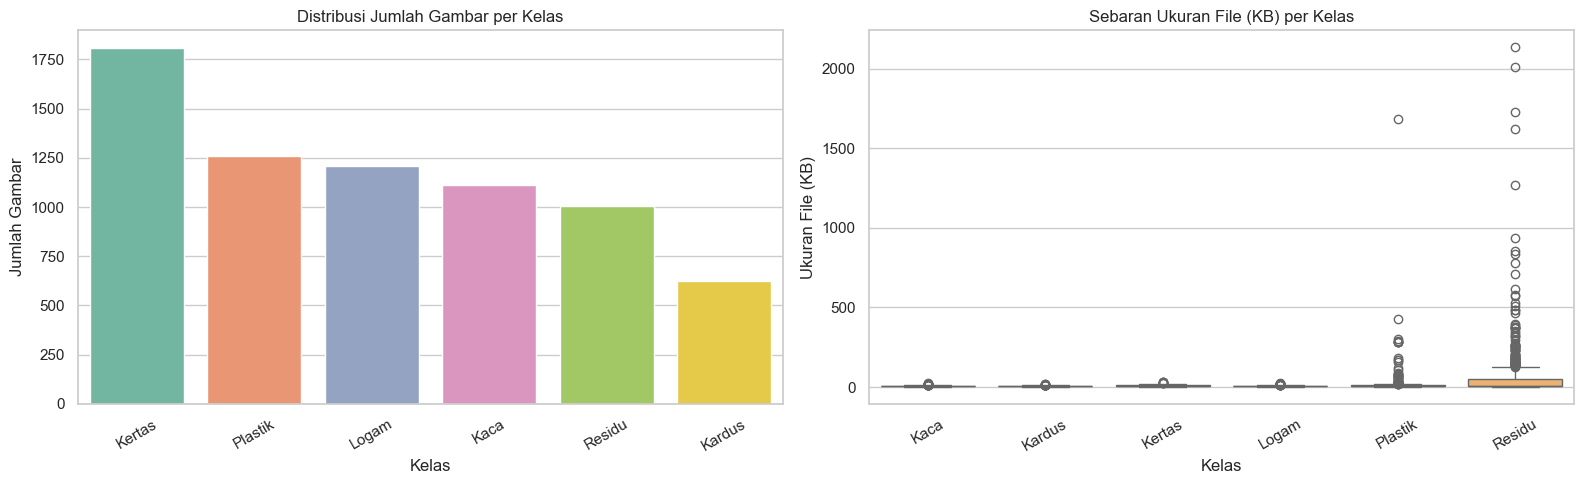

In [6]:
print("Ukuran data bersih:", clean_df.shape)

print("\nStatistik numerik:")
display(clean_df[["width", "height", "aspect_ratio", "pixels", "file_size_kb"]].describe().T)

class_summary = (
    clean_df.groupby("class_label")
    .agg(
        n_images=("file_name", "count"),
        avg_width=("width", "mean"),
        avg_height=("height", "mean"),
        median_file_size_kb=("file_size_kb", "median"),
    )
    .sort_values("n_images", ascending=False)
)

class_summary["pct"] = (class_summary["n_images"] / class_summary["n_images"].sum() * 100).round(2)
display(class_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(
    data=clean_df,
    x="class_label",
    order=clean_df["class_label"].value_counts().index,
    palette="Set2",
    ax=axes[0],
)
axes[0].set_title("Distribusi Jumlah Gambar per Kelas")
axes[0].set_xlabel("Kelas")
axes[0].set_ylabel("Jumlah Gambar")
axes[0].tick_params(axis="x", rotation=30)

sns.boxplot(data=clean_df, x="class_label", y="file_size_kb", palette="Set3", ax=axes[1])
axes[1].set_title("Sebaran Ukuran File (KB) per Kelas")
axes[1].set_xlabel("Kelas")
axes[1].set_ylabel("Ukuran File (KB)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

**Insight:**
- EDA menunjukkan gambaran umum struktur data bersih, termasuk ringkasan statistik dimensi dan ukuran file.
- Perbandingan antarkelas memperlihatkan potensi ketidakseimbangan jumlah data dan perbedaan karakteristik visual yang relevan untuk modeling.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana distribusi jumlah gambar per kategori dan tingkat ketidakseimbangannya?

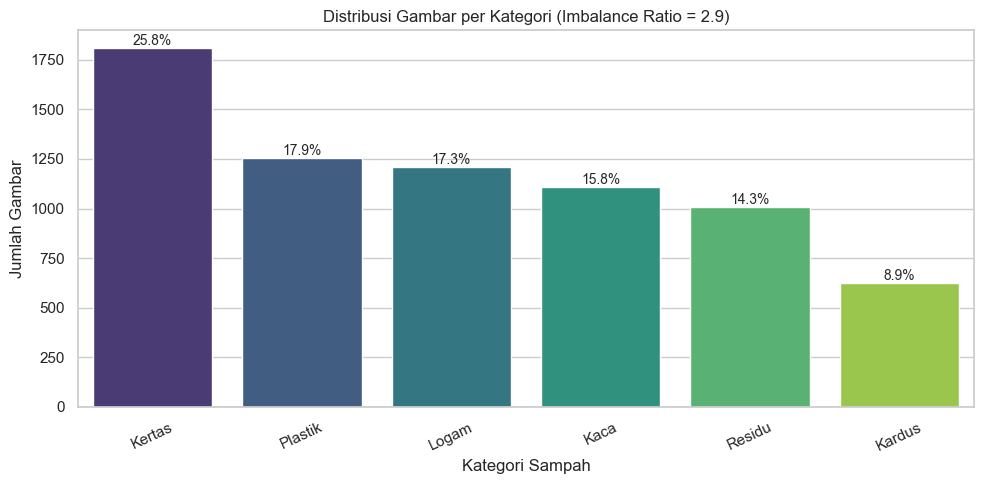

,class_label,n_images,pct
0,Kertas,1807,25.762760
1,Plastik,1257,17.921300
2,Logam,1210,17.251212
3,Kaca,1110,15.825492
4,Residu,1006,14.342743
5,Kardus,624,8.896493


In [7]:
q1_dist = clean_df["class_label"].value_counts().reset_index()
q1_dist.columns = ["class_label", "n_images"]
q1_dist["pct"] = q1_dist["n_images"] / q1_dist["n_images"].sum() * 100

max_count = q1_dist["n_images"].max()
min_count = q1_dist["n_images"].min()
imbalance_ratio = round(max_count / min_count, 2)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=q1_dist, x="class_label", y="n_images", palette="viridis")

for i, row in q1_dist.iterrows():
    ax.text(i, row["n_images"] + 15, f"{row['pct']:.1f}%", ha="center", fontsize=10)

plt.title(f"Distribusi Gambar per Kategori (Imbalance Ratio = {imbalance_ratio})")
plt.xlabel("Kategori Sampah")
plt.ylabel("Jumlah Gambar")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

display(q1_dist)

### Pertanyaan 2: Apakah ukuran file dan resolusi gambar berbeda antar kategori?

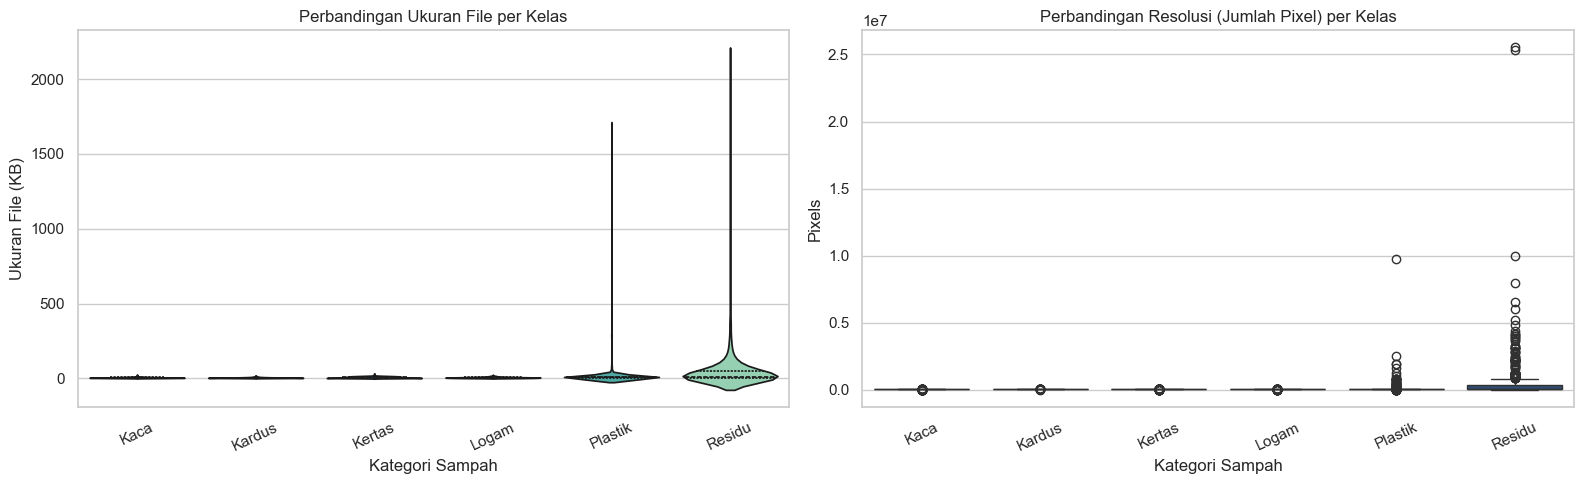

,median_file_size_kb,mean_file_size_kb,median_pixels,mean_aspect_ratio
class_label,,,,
Residu,8.06,53.00,50625.0,1.24
Plastik,7.68,12.67,50400.0,1.36
Kertas,7.40,8.30,50400.0,1.27
Logam,6.18,6.80,50400.0,1.22
Kaca,5.43,5.97,50401.0,1.09
Kardus,4.99,5.52,50437.0,1.25


In [8]:
q2_stats = (
    clean_df.groupby("class_label")
    .agg(
        median_file_size_kb=("file_size_kb", "median"),
        mean_file_size_kb=("file_size_kb", "mean"),
        median_pixels=("pixels", "median"),
        mean_aspect_ratio=("aspect_ratio", "mean"),
    )
    .sort_values("median_file_size_kb", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.violinplot(data=clean_df, x="class_label", y="file_size_kb", inner="quartile", palette="mako", ax=axes[0])
axes[0].set_title("Perbandingan Ukuran File per Kelas")
axes[0].set_xlabel("Kategori Sampah")
axes[0].set_ylabel("Ukuran File (KB)")
axes[0].tick_params(axis="x", rotation=25)

sns.boxplot(data=clean_df, x="class_label", y="pixels", palette="crest", ax=axes[1])
axes[1].set_title("Perbandingan Resolusi (Jumlah Pixel) per Kelas")
axes[1].set_xlabel("Kategori Sampah")
axes[1].set_ylabel("Pixels")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

display(q2_stats.round(2))

**Insight:**
- Kategori dengan jumlah gambar terbanyak dan tersedikit dapat digunakan untuk menghitung imbalance ratio sebagai indikator kesiapan data training.
- Perbedaan ukuran file dan resolusi antar kelas menunjukkan kebutuhan preprocessing yang konsisten (misalnya resize, normalisasi, atau augmentasi selektif).

## Analisis Lanjutan (Opsional)

In [9]:
# Analisis opsional: simulasi bobot kelas untuk menangani class imbalance pada tahap modeling
class_count = clean_df["class_label"].value_counts().sort_index()
class_weight = (class_count.sum() / (len(class_count) * class_count)).round(4)

class_weight_df = pd.DataFrame(
    {
        "class_label": class_weight.index,
        "n_images": class_count.values,
        "suggested_class_weight": class_weight.values,
    }
).sort_values("suggested_class_weight", ascending=False)

display(class_weight_df)

,class_label,n_images,suggested_class_weight
1,Kardus,624,1.8734
5,Residu,1006,1.1620
0,Kaca,1110,1.0532
3,Logam,1210,0.9661
4,Plastik,1257,0.9300
2,Kertas,1807,0.6469


## Conclusion

- Pertanyaan 1: Distribusi gambar per kategori tidak sepenuhnya seimbang. Kategori dominan dan kategori minoritas perlu diperhatikan karena dapat memengaruhi performa model klasifikasi.
- Pertanyaan 2: Terdapat perbedaan karakteristik ukuran file dan resolusi antar kategori. Oleh karena itu, preprocessing terstandar (resize, validasi kualitas gambar, dan penanganan imbalance) penting sebelum tahap modeling.